### Descriptive analysis of the data
Our dataset comes from the **Garbage Classification** dataset.  
It contains **images of waste** grouped into six categories: *cardboard, glass, metal, paper, plastic,* and *trash*.  
The dataset is fairly balanced, with roughly the same number of images per class.  
Each image has different lighting, backgrounds, and angles, which makes classification more realistic and challenging.

---

### Implementation of the necessary pre-processing
Before training, each image is:
- **Resized** to a fixed shape of *(224×224)* pixels.  
- **Converted to grayscale** for handcrafted features (HOG and LBP).  
- **Contrast-enhanced** using *CLAHE* and lightly blurred to reduce noise.  
- For deep learning, we applied **image normalization** and **data augmentation** (random flips, rotations, zooms).  

These steps help make the model more robust to lighting and shape variations.

---

### Formalisation of the problem
The goal is to **classify an image of a waste item into its correct category**.  
Formally, this is a **supervised multi-class classification problem** with six possible labels.  
**Input:** an RGB image.  
**Output:** one class label ∈ {cardboard, glass, metal, paper, plastic, trash}.  

---

### Selection of a baseline model and implementation
We started with **handcrafted features** (HOG and LBP) combined with classical machine learning models such as:
- **SVM**, **Random Forest**, **KNN**, and **HistGradientBoosting**.  

This served as our **baseline**, allowing us to measure how much traditional methods can achieve before moving to deep learning.  
Then, we implemented **deep feature extraction** using **ResNet50** and **Vision Transformer (ViT)** combined with **Random Forest** or **Gradient Boosting** classifiers, reaching the best performance (up to ~97% accuracy).


In [ ]:
from pathlib import Path
import numpy as np, json, joblib, time, warnings
warnings.filterwarnings("ignore")
from sklearn.model_selection import StratifiedKFold, train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score, f1_score
)
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except Exception:
    HAS_XGB = False
from skimage.io import imread
from skimage.transform import resize
from skimage.color import rgb2gray
from skimage.feature import hog, local_binary_pattern
import matplotlib.pyplot as plt
import pandas as pd

In [ ]:

DATA_DIR = Path(r"C:\Users\hugop\OneDrive\Bureau\ML_project\data")
IMG_SIZE = (224, 224)
HOG_PIXELS_PER_CELL = (16,16)
HOG_CELLS_PER_BLOCK = (2,2)
HOG_ORIENTATIONS = 9
LBP_P, LBP_R = 8, 1  
LBP_BINS = LBP_P + 2 
SEED = 42
N_FOLDS = 5

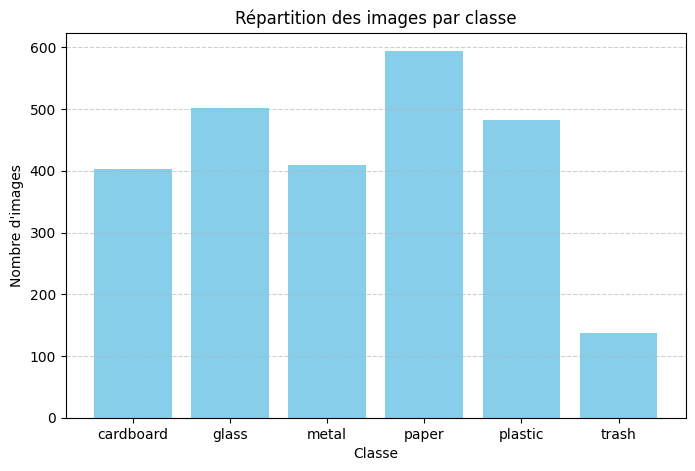

 Nombre total d'images : 2527

  cardboard  :  403 images ( 15.9 %)
  glass      :  501 images ( 19.8 %)
  metal      :  410 images ( 16.2 %)
  paper      :  594 images ( 23.5 %)
  plastic    :  482 images ( 19.1 %)
  trash      :  137 images (  5.4 %)

Classe la plus grande : 'paper' (594)
Classe la plus petite : 'trash' (137)
Ratio max/min = 4.34
Déséquilibre modéré — recommander class_weight='balanced'


In [ ]:

counts = {d.name: len(list(d.glob("*.*"))) for d in DATA_DIR.iterdir() if d.is_dir()}
total = sum(counts.values())
plt.figure(figsize=(8,5))
plt.bar(counts.keys(), counts.values(), color="skyblue")
plt.title("Répartition des images par classe")
plt.xlabel("Classe")
plt.ylabel("Nombre d'images")
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()
print(f" Nombre total d'images : {total}\n")
for k, v in counts.items():
    print(f"  {k:<10} : {v:>4} images ({v/total*100:5.1f} %)")
max_class = max(counts, key=counts.get)
min_class = min(counts, key=counts.get)
ratio = counts[max_class] / max(1, counts[min_class])
print(f"\nClasse la plus grande : '{max_class}' ({counts[max_class]})")
print(f"Classe la plus petite : '{min_class}' ({counts[min_class]})")
print(f"Ratio max/min = {ratio:.2f}")
if ratio < 2:
    print("Données équilibrées (faible déséquilibre)")
elif ratio < 10:
    print("Déséquilibre modéré — recommander class_weight='balanced'")
else:
    print("Déséquilibre fort — recommander oversampling ou data augmentation")


In [ ]:
def extract_features(img, use_hog=True, use_lbp=True):
    img = resize(img, IMG_SIZE, anti_aliasing=True)
    gray = rgb2gray(img)
    feats = []
    if use_hog:
        h = hog(
            gray,
            orientations=HOG_ORIENTATIONS,
            pixels_per_cell=HOG_PIXELS_PER_CELL,
            cells_per_block=HOG_CELLS_PER_BLOCK,
            feature_vector=True
        )
        feats.append(h.astype(np.float32))
    if use_lbp:
        lbp = local_binary_pattern(gray, P=LBP_P, R=LBP_R, method='uniform')
        hist, _ = np.histogram(lbp, bins=np.arange(0, LBP_BINS+1), range=(0, LBP_BINS), density=True)
        feats.append(hist.astype(np.float32))
    return np.concatenate(feats)
classes = sorted([d.name for d in DATA_DIR.iterdir() if d.is_dir()])
X, y, paths = [], [], []
t0 = time.time()
for ci, cname in enumerate(classes):
    for p in (DATA_DIR / cname).glob("*.*"):
        try:
            img = imread(p)
            feats = extract_features(img, use_hog=True, use_lbp=True)
            X.append(feats); y.append(ci); paths.append(str(p))
        except Exception:
            pass
X, y = np.array(X), np.array(y)
print(f"Features: X={X.shape}, n_classes={len(classes)}, time={time.time()-t0:.1f}s")
with open("labels.json","w", encoding="utf-8") as f:
    json.dump(classes, f, ensure_ascii=False, indent=2)


Features: X=(2527, 6094), n_classes=6, time=114.8s


In [6]:
X_tr, X_te, y_tr, y_te, paths_tr, paths_te = train_test_split(
    X, y, paths, test_size=0.2, random_state=SEED, stratify=y
)
print("Train:", X_tr.shape, "Test:", X_te.shape)


Train: (2021, 6094) Test: (506, 6094)


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except Exception:
    HAS_XGB = False
models = {
    "SVM-RBF": Pipeline([
        ("scaler", StandardScaler(with_mean=False)),
        ("clf", SVC(C=10, gamma="scale", random_state=SEED))
    ]),
    "RandomForest": Pipeline([
        ("clf", RandomForestClassifier(
            n_estimators=600, max_features="sqrt", random_state=SEED, n_jobs=-1
        ))
    ]),
    "KNN": Pipeline([
        ("scaler", StandardScaler(with_mean=False)),
        ("clf", KNeighborsClassifier(n_neighbors=5))
    ]),
    "HistGB": Pipeline([
        ("clf", HistGradientBoostingClassifier(
            learning_rate=0.1,
            max_iter=300,
            early_stopping=True,
            validation_fraction=0.1,
            random_state=SEED
        ))
    ])
}
if HAS_XGB:
    models["XGBoost"] = Pipeline([
        ("clf", XGBClassifier(
            n_estimators=600, learning_rate=0.05, max_depth=6,
            subsample=0.9, colsample_bytree=0.9,
            random_state=SEED, n_jobs=-1, tree_method="hist"
        ))
    ])
list(models.keys())


['SVM-RBF', 'RandomForest', 'KNN', 'HistGB']

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_validate
import time, pandas as pd
rows = []
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)
for name, pipe in models.items():
    t0 = time.time()
    scores = cross_validate(
        pipe, X_tr, y_tr, cv=cv,
        scoring={'acc':'accuracy', 'f1m':'f1_macro'},
        n_jobs=1,            # <— clé anti-freeze dans notebook Windows
        return_train_score=False
    )
    rows.append({
        "Model": name,
        "Acc_mean": scores['test_acc'].mean(), "Acc_std": scores['test_acc'].std(),
        "F1m_mean": scores['test_f1m'].mean(), "F1m_std": scores['test_f1m'].std(),
        "TrainCV_time_s": time.time()-t0
    })
    print(f"{name:16s} | Acc {scores['test_acc'].mean():.3f}±{scores['test_acc'].std():.3f} | "
          f"F1m {scores['test_f1m'].mean():.3f}±{scores['test_f1m'].std():.3f}")
results = pd.DataFrame(rows).sort_values("F1m_mean", ascending=False).reset_index(drop=True)
results



SVM-RBF          | Acc 0.606±0.013 | F1m 0.584±0.022
RandomForest     | Acc 0.586±0.016 | F1m 0.540±0.018
KNN              | Acc 0.439±0.008 | F1m 0.400±0.014
HistGB           | Acc 0.588±0.011 | F1m 0.564±0.018


,Model,Acc_mean,Acc_std,F1m_mean,F1m_std,TrainCV_time_s
0,SVM-RBF,0.605641,0.013332,0.584078,0.021811,30.767782
1,HistGB,0.587835,0.010980,0.563808,0.018051,252.319289
2,RandomForest,0.585859,0.015756,0.540273,0.018237,16.860207
3,KNN,0.438888,0.007847,0.400000,0.014404,2.942725


Best by CV (F1-macro): SVM-RBF

Test set performance
Accuracy: 0.6620553359683794
F1-macro: 0.657472537952114

Classification report:

              precision    recall  f1-score   support

   cardboard      0.737     0.691     0.713        81
       glass      0.618     0.680     0.648       100
       metal      0.603     0.537     0.568        82
       paper      0.728     0.832     0.776       119
     plastic      0.557     0.557     0.557        97
       trash      1.000     0.519     0.683        27

    accuracy                          0.662       506
   macro avg      0.707     0.636     0.657       506
weighted avg      0.669     0.662     0.660       506



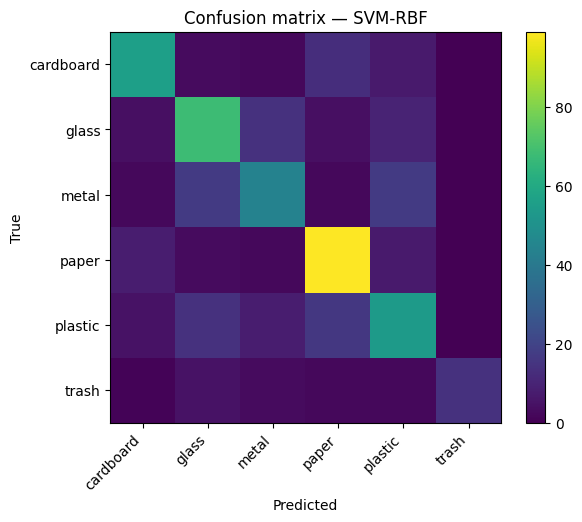

['models\\handcrafted\\SVM-RBF.joblib']

In [9]:
best_name = results.iloc[0]["Model"]
best_pipe = models[best_name]
print("Best by CV (F1-macro):", best_name)
best_pipe.fit(X_tr, y_tr)
y_pred = best_pipe.predict(X_te)
print("\nTest set performance")
print("Accuracy:", accuracy_score(y_te, y_pred))
print("F1-macro:", f1_score(y_te, y_pred, average="macro"))
print("\nClassification report:\n")
print(classification_report(y_te, y_pred, target_names=classes, digits=3))
cm = confusion_matrix(y_te, y_pred)
plt.figure(figsize=(6,5))
plt.imshow(cm, interpolation='nearest')
plt.title(f"Confusion matrix — {best_name}")
plt.colorbar()
tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes, rotation=45, ha="right")
plt.yticks(tick_marks, classes)
plt.tight_layout()
plt.xlabel('Predicted'); plt.ylabel('True')
plt.show()
Path("models/handcrafted").mkdir(parents=True, exist_ok=True)
joblib.dump(best_pipe, Path("models/handcrafted") / f"{best_name.replace(' ','_')}.joblib")


Images test : [WindowsPath('C:/Users/hugop/OneDrive/Bureau/ML_PROJECT/data/glass/glass1.jpg'), WindowsPath('C:/Users/hugop/OneDrive/Bureau/ML_PROJECT/data/paper/paper1.jpg'), WindowsPath('C:/Users/hugop/OneDrive/Bureau/ML_PROJECT/data/plastic/plastic1.jpg')]


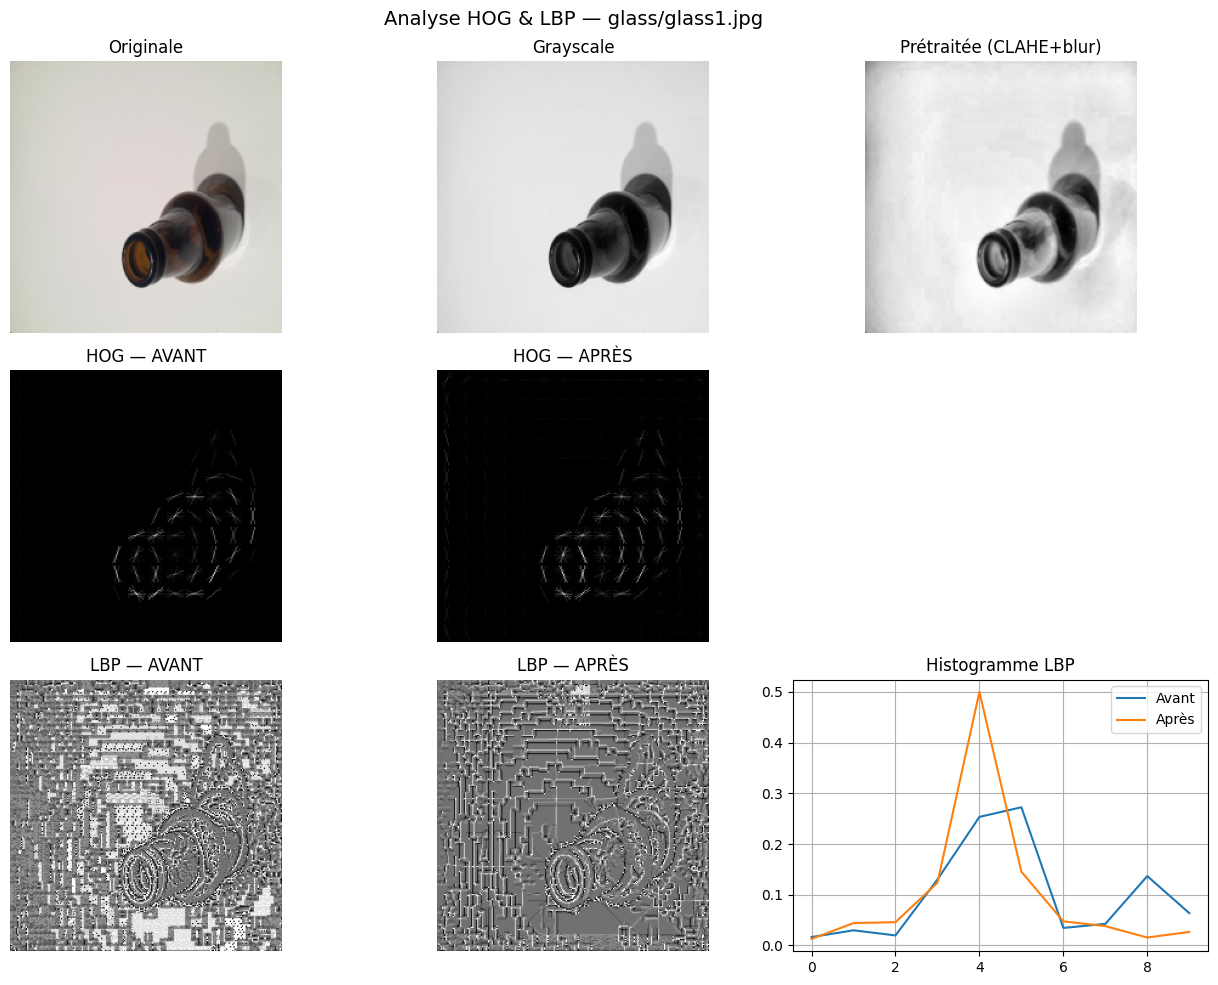

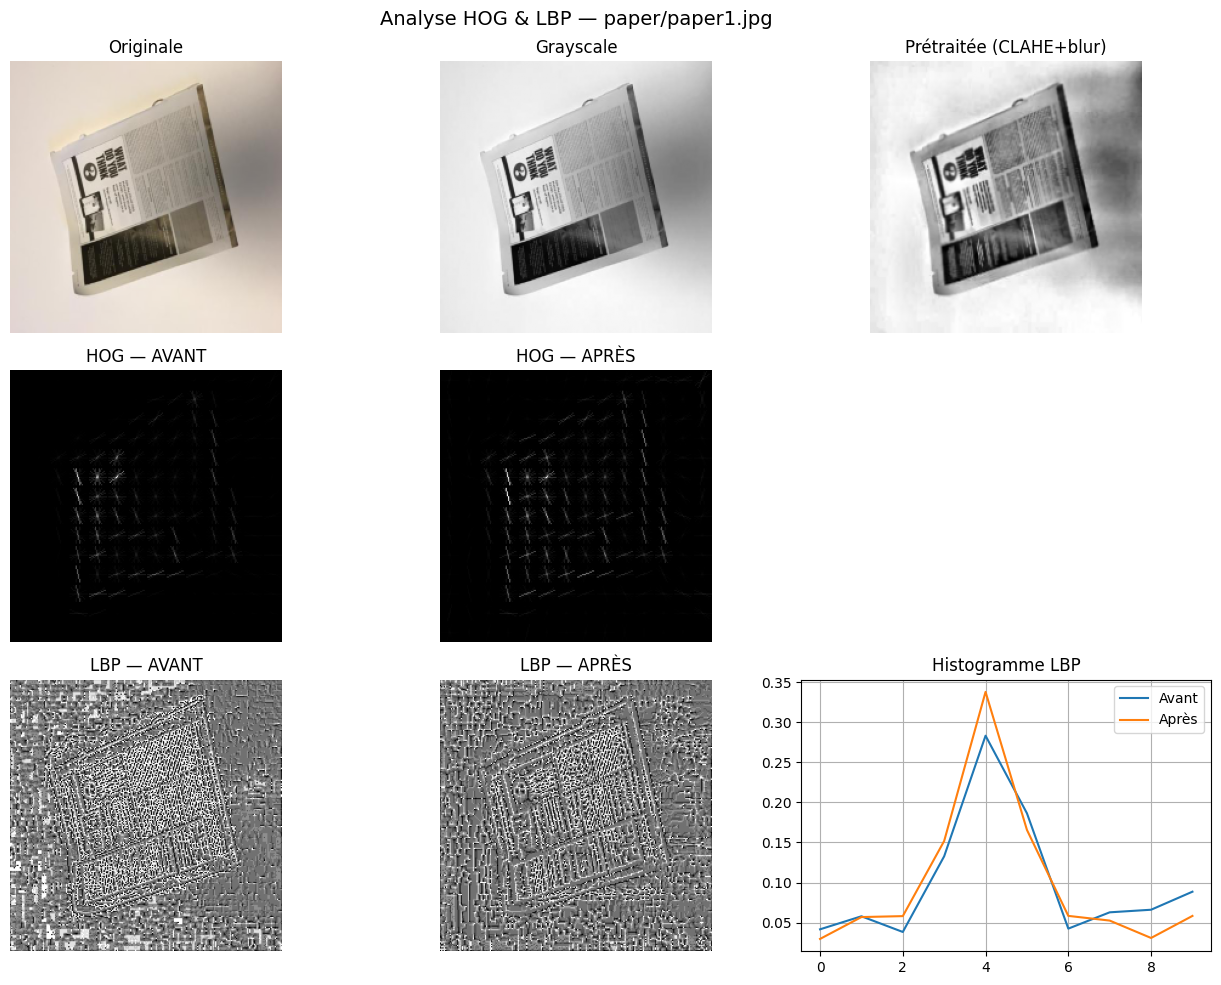

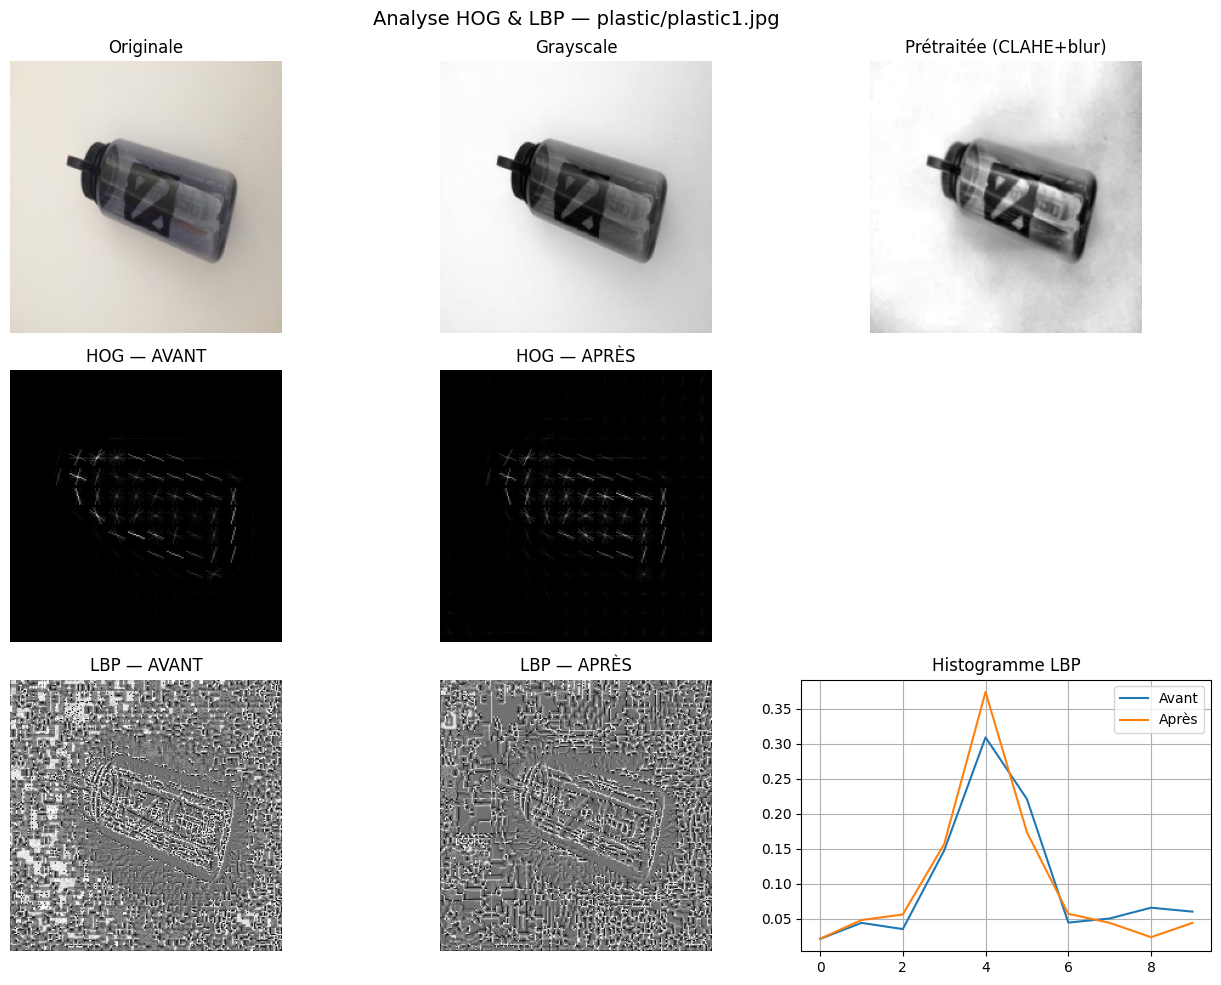

In [ ]:
from skimage.io import imread
from skimage.transform import resize
from skimage.color import rgb2gray
from skimage.feature import hog, local_binary_pattern
from skimage import exposure
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
DATA_DIR = Path(r"C:\Users\hugop\OneDrive\Bureau\ML_PROJECT\data")
#ne pas toucher c'est les paramètres
IMG_SIZE = (224, 224)
LBP_P, LBP_R = 8, 1
LBP_BINS = LBP_P + 2
def preprocess_gray(img_gray):
    """Prétraitement"""
    clahe = exposure.equalize_adapthist(img_gray, clip_limit=0.02)
    blurred = resize(clahe, (int(IMG_SIZE[0]*0.98), int(IMG_SIZE[1]*0.98)), anti_aliasing=True)
    blurred = resize(blurred, IMG_SIZE, anti_aliasing=True)
    return blurred

def compute_hog(gray, visualize=True):
    return hog(
        gray,
        orientations=9,
        pixels_per_cell=(16,16),
        cells_per_block=(2,2),
        visualize=visualize
    )
def compute_lbp(gray):
    lbp = local_binary_pattern(gray, P=LBP_P, R=LBP_R, method='uniform')
    hist, _ = np.histogram(lbp, bins=np.arange(0, LBP_BINS+1), range=(0, LBP_BINS), density=True)
    return lbp, hist
#tst
sample_paths = []
for cname in ["glass", "paper", "plastic"]:
    p = next((DATA_DIR/cname).glob("*.*"))
    sample_paths.append(p)
print("Images test :", sample_paths)
for p in sample_paths:
    img = imread(p)
    img_resized = resize(img, IMG_SIZE, anti_aliasing=True)
    gray = rgb2gray(img_resized)
    gray_pp = preprocess_gray(gray)
    _, hog_vis_before = compute_hog(gray, visualize=True)
    _, hog_vis_after = compute_hog(gray_pp, visualize=True)
    lbp_before, hist_before = compute_lbp(gray)
    lbp_after, hist_after = compute_lbp(gray_pp)
    fig = plt.figure(figsize=(13,10))
    fig.suptitle(f"Analyse HOG & LBP — {p.parent.name}/{p.name}", fontsize=14)
    ax1 = plt.subplot(3,3,1); ax1.imshow(img_resized); ax1.set_title("Originale"); ax1.axis('off')
    ax2 = plt.subplot(3,3,2); ax2.imshow(gray, cmap='gray'); ax2.set_title("Grayscale"); ax2.axis('off')
    ax3 = plt.subplot(3,3,3); ax3.imshow(gray_pp, cmap='gray'); ax3.set_title("Prétraitée (CLAHE+blur)"); ax3.axis('off')
    ax4 = plt.subplot(3,3,4); ax4.imshow(hog_vis_before, cmap='gray'); ax4.set_title("HOG — AVANT"); ax4.axis('off')
    ax5 = plt.subplot(3,3,5); ax5.imshow(hog_vis_after, cmap='gray'); ax5.set_title("HOG — APRÈS"); ax5.axis('off')
    ax6 = plt.subplot(3,3,7); ax6.imshow(lbp_before, cmap='gray'); ax6.set_title("LBP — AVANT"); ax6.axis('off')
    ax7 = plt.subplot(3,3,8); ax7.imshow(lbp_after, cmap='gray'); ax7.set_title("LBP — APRÈS"); ax7.axis('off')
    ax8 = plt.subplot(3,3,9)
    ax8.plot(hist_before, label="Avant")
    ax8.plot(hist_after, label="Après")
    ax8.set_title("Histogramme LBP")
    ax8.legend(); ax8.grid()
    plt.tight_layout()
    plt.show()
